In [1]:
!pip install transformers datasets accelerate bitsandbytes peft
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install scikit-learn imbalanced-learn pandas numpy matplotlib seaborn
!pip install onnxruntime-gpu wandb plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 MB 29.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 89.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 82.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━

In [2]:
import torch
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
from imblearn.over_sampling import SMOTE
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                         TrainingArguments, Trainer, BitsAndBytesConfig)
from peft import LoraConfig, get_peft_model, TaskType
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print(f"GPU Available: {torch.cuda.is_available()}")
print(f"GPU Name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

2025-08-12 12:13:45.880529: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755000826.062463      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755000826.115829      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


GPU Available: True
GPU Name: Tesla P100-PCIE-16GB


In [3]:
log_data = []
with open('/kaggle/input/mylogdataset/subset/HDFS_subset.log', 'r') as f:
    for line in f:
        pattern = r'(\d{6}\s\d{6})\s(\d+)\s(\w+)\s([^:]+):\s(.+)'
        match = re.match(pattern, line.strip())
        if match:
            timestamp, thread, level, component, message = match.groups()

            block_match = re.search(r'(blk_-?\d+)', message)
            block_id = block_match.group(1) if block_match else None

            log_data.append({
                'timestamp': timestamp,
                'thread': thread,
                'level': level,
                'component': component,
                'message': message,
                'block_id': block_id,
                'full_log': line.strip()
            })

logs_df = pd.DataFrame(log_data)
print(f"Total logs parsed: {len(logs_df)}")

labels_df = pd.read_csv('/kaggle/input/mylogdataset/subset/anomaly_label_subset.csv')
labels_df.columns = ['block_id', 'label']

merged_df = logs_df.merge(labels_df, on='block_id', how='inner')
merged_df['label_num'] = (merged_df['label'] == 'Anomaly').astype(int)

print(f"Normal logs: {(merged_df['label_num'] == 0).sum()}")
print(f"Anomaly logs: {(merged_df['label_num'] == 1).sum()}")

Total logs parsed: 1117995
Normal logs: 1089673
Anomaly logs: 28322


In [4]:
merged_df['log_length'] = merged_df['message'].str.len()
merged_df['has_ip'] = merged_df['message'].str.contains(r'\d+\.\d+\.\d+\.\d+').astype(int)
merged_df['has_error'] = merged_df['message'].str.contains('error|Error|ERROR', case=False).astype(int)
merged_df['component_type'] = merged_df['component'].str.split('.').str[-1]

merged_df['model_input'] = merged_df.apply(lambda x:
    f"Component: {x['component_type']} Level: {x['level']} Message: {x['message'][:200]}", axis=1)

X = merged_df['model_input'].values
y = merged_df['label_num'].values

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.1, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.125, stratify=y_temp, random_state=42)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")
print(f"Train anomaly ratio: {y_train.sum() / len(y_train):.3f}")

Train: 880420, Val: 125775, Test: 111800
Train anomaly ratio: 0.025


In [5]:
feature_vectorizer = merged_df[['log_length', 'has_ip', 'has_error']].iloc[:len(X_train)].values

smote = SMOTE(random_state=42, sampling_strategy=0.3)
X_train_features_balanced, y_train_balanced = smote.fit_resample(feature_vectorizer, y_train)

balanced_indices = []
normal_indices = np.where(y_train == 0)[0]
anomaly_indices = np.where(y_train == 1)[0]

balanced_indices.extend(range(len(y_train)))

n_synthetic = len(y_train_balanced) - len(y_train)
synthetic_indices = np.random.choice(anomaly_indices, n_synthetic, replace=True)
balanced_indices.extend(synthetic_indices)

X_train_balanced = np.concatenate([X_train, X_train[synthetic_indices]])
y_train_balanced = np.concatenate([y_train, y_train[synthetic_indices]])

print(f"Balanced train set: {len(y_train_balanced)} samples")
print(f"Normal: {(y_train_balanced == 0).sum()}, Anomaly: {(y_train_balanced == 1).sum()}")

Balanced train set: 1115550 samples
Normal: 858116, Anomaly: 257434


In [6]:
from torch.utils.data import Dataset

class LogDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=64):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

model_name = "huawei-noah/TinyBERT_General_4L_312D"
tokenizer = AutoTokenizer.from_pretrained(model_name)

train_dataset = LogDataset(X_train_balanced, y_train_balanced, tokenizer)
val_dataset = LogDataset(X_val, y_val, tokenizer)

print("Datasets created successfully")

config.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Datasets created successfully


In [7]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    device_map="auto"
)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    inference_mode=False,
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["query", "key", "value"]
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

pytorch_model.bin:   0%|          | 0.00/62.7M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at huawei-noah/TinyBERT_General_4L_312D and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/62.7M [00:00<?, ?B/s]

trainable params: 120,434 || all params: 14,471,308 || trainable%: 0.8322


In [10]:
training_args = TrainingArguments(
    output_dir='/kaggle/working/SLM/slm_results/',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=2,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir='/kaggle/working//SLM/logs/',
    logging_steps=50,
    eval_strategy="steps",
    eval_steps=500,
    save_steps=500,
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1",
    greater_is_better=True,
    report_to="none",
    fp16=True,
)

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    f1 = f1_score(labels, predictions, average='weighted')
    return {"f1": f1}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


In [11]:
print("Starting SLM training...")
trainer.train()

trainer.save_model("/kaggle/working//SLM/slm_final")
print("SLM training completed!")

Starting SLM training...


Step,Training Loss,Validation Loss,F1
500,0.544100,0.280698,0.962166
1000,0.530200,0.275855,0.962166
1500,0.529500,0.270124,0.962166
2000,0.536700,0.268722,0.962166
2500,0.527500,0.270705,0.962166
3000,0.543600,0.287486,0.963326
3500,0.523300,0.268187,0.965682
4000,0.497200,0.264934,0.964778
4500,0.500600,0.276210,0.962206
5000,0.498500,0.255250,0.957585


SLM training completed!


In [12]:
!zip -r slm_final.zip /kaggle/working/SLM/slm_final
!mv slm_final.zip /kaggle/working/

  adding: kaggle/working/SLM/slm_final/ (stored 0%)
  adding: kaggle/working/SLM/slm_final/adapter_model.safetensors (deflated 7%)
  adding: kaggle/working/SLM/slm_final/adapter_config.json (deflated 54%)
  adding: kaggle/working/SLM/slm_final/README.md (deflated 66%)
  adding: kaggle/working/SLM/slm_final/training_args.bin (deflated 51%)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


mv: 'slm_final.zip' and '/kaggle/working/slm_final.zip' are the same file


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [13]:
model.eval()

predictions = trainer.predict(val_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_prob = torch.softmax(torch.tensor(predictions.predictions), dim=1).numpy()

print("SLM Validation Results:")
print(classification_report(y_val, y_pred))

max_probs = np.max(y_prob, axis=1)
uncertain_mask = (max_probs >= 0.3) & (max_probs <= 0.9)

X_uncertain = X_val[uncertain_mask]
y_uncertain = y_val[uncertain_mask]
prob_uncertain = max_probs[uncertain_mask]

print(f"Uncertain samples for LLM: {len(X_uncertain)} ({len(X_uncertain)/len(X_val)*100:.1f}%)")

SLM Validation Results:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99    122589
           1       0.37      0.17      0.23      3186

    accuracy                           0.97    125775
   macro avg       0.68      0.58      0.61    125775
weighted avg       0.96      0.97      0.97    125775

Uncertain samples for LLM: 88153 (70.1%)


In [27]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

llm_model_name = "distilbert-base-uncased"
llm_tokenizer = AutoTokenizer.from_pretrained(llm_model_name)

llm_model = AutoModelForSequenceClassification.from_pretrained(
    llm_model_name,
    num_labels=2,
    device_map="auto"
)

llm_lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    inference_mode=False,
    r=64,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["q_lin", "k_lin", "v_lin"]
)

llm_model = get_peft_model(llm_model, llm_lora_config)
print("LLM model loaded with LoRA!")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


LLM model loaded with LoRA!


In [28]:
llm_texts = [f"Classify this HDFS log as Normal or Anomaly: {text}" for text in X_uncertain]

class LLMDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self): 
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

X_llm_train, X_llm_val, y_llm_train, y_llm_val = train_test_split(
    llm_texts, y_uncertain, test_size=0.2, stratify=y_uncertain, random_state=42
)

llm_train_dataset = LLMDataset(X_llm_train, y_llm_train, llm_tokenizer)
llm_val_dataset = LLMDataset(X_llm_val, y_llm_val, llm_tokenizer)

llm_training_args = TrainingArguments(
    output_dir='/kaggle/working/LLM/llm_results',
    num_train_epochs=3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=4,
    warmup_steps=50,
    weight_decay=0.01,
    logging_steps=25,
    eval_strategy="steps",
    eval_steps=100,
    save_steps=200,
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1",
    fp16=True,
    report_to="none"
)

llm_trainer = Trainer(
    model=llm_model,
    args=llm_training_args,
    train_dataset=llm_train_dataset,
    eval_dataset=llm_val_dataset,
    compute_metrics=compute_metrics,
)

No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


In [29]:
print("Starting LLM fine-tuning on uncertain cases...")
llm_trainer.train()
print("LLM training completed!")

Starting LLM fine-tuning on uncertain cases...


Step,Training Loss,Validation Loss,F1
100,0.106300,0.129956,0.958339
200,0.165000,0.127265,0.958339
300,0.163400,0.128437,0.958339
400,0.109700,0.129632,0.958339
500,0.154000,0.127132,0.958339
600,0.110200,0.131258,0.958339
700,0.169300,0.127160,0.958339
800,0.111000,0.128263,0.958339
900,0.095200,0.129458,0.958339
1000,0.133800,0.127623,0.958339


LLM training completed!


In [30]:
llm_trainer.save_model("/kaggle/working/LLM/llm_final")
!zip -r llm_final.zip /kaggle/working/LLM/llm_final
!mv slm_final.zip /kaggle/working/

  adding: kaggle/working/LLM/llm_final/ (stored 0%)
  adding: kaggle/working/LLM/llm_final/adapter_model.safetensors

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


 (deflated 7%)
  adding: kaggle/working/LLM/llm_final/adapter_config.json (deflated 55%)
  adding: kaggle/working/LLM/llm_final/README.md (deflated 66%)
  adding: kaggle/working/LLM/llm_final/training_args.bin (deflated 51%)
mv: 'slm_final.zip' and '/kaggle/working/slm_final.zip' are the same file


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [31]:
slm_model = AutoModelForSequenceClassification.from_pretrained("/kaggle/working/SLM/slm_final")
slm_model.eval()

test_dataset = LogDataset(X_test, y_test, tokenizer)

slm_predictions = trainer.predict(test_dataset)
slm_probs = torch.softmax(torch.tensor(slm_predictions.predictions), dim=1).numpy()
slm_pred = np.argmax(slm_predictions.predictions, axis=1)
slm_confidence = np.max(slm_probs, axis=1)

test_uncertain_mask = (slm_confidence >= 0.3) & (slm_confidence <= 0.9)
X_test_uncertain = X_test[test_uncertain_mask]
y_test_uncertain = y_test[test_uncertain_mask]

if len(X_test_uncertain) > 0:
    llm_test_texts = [f"Classify this HDFS log as Normal or Anomaly: {text}" for text in X_test_uncertain]
    llm_test_dataset = LLMDataset(llm_test_texts, y_test_uncertain, llm_tokenizer)
    
    llm_predictions = llm_trainer.predict(llm_test_dataset)
    llm_pred = np.argmax(llm_predictions.predictions, axis=1)
    
    final_predictions = slm_pred.copy()
    final_predictions[test_uncertain_mask] = llm_pred
else:
    final_predictions = slm_pred

print("Final Ensemble Test Results:")
print(classification_report(y_test, final_predictions))

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at huawei-noah/TinyBERT_General_4L_312D and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Final Ensemble Test Results:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    108968
           1       0.62      0.10      0.18      2832

    accuracy                           0.98    111800
   macro avg       0.80      0.55      0.58    111800
weighted avg       0.97      0.98      0.97    111800



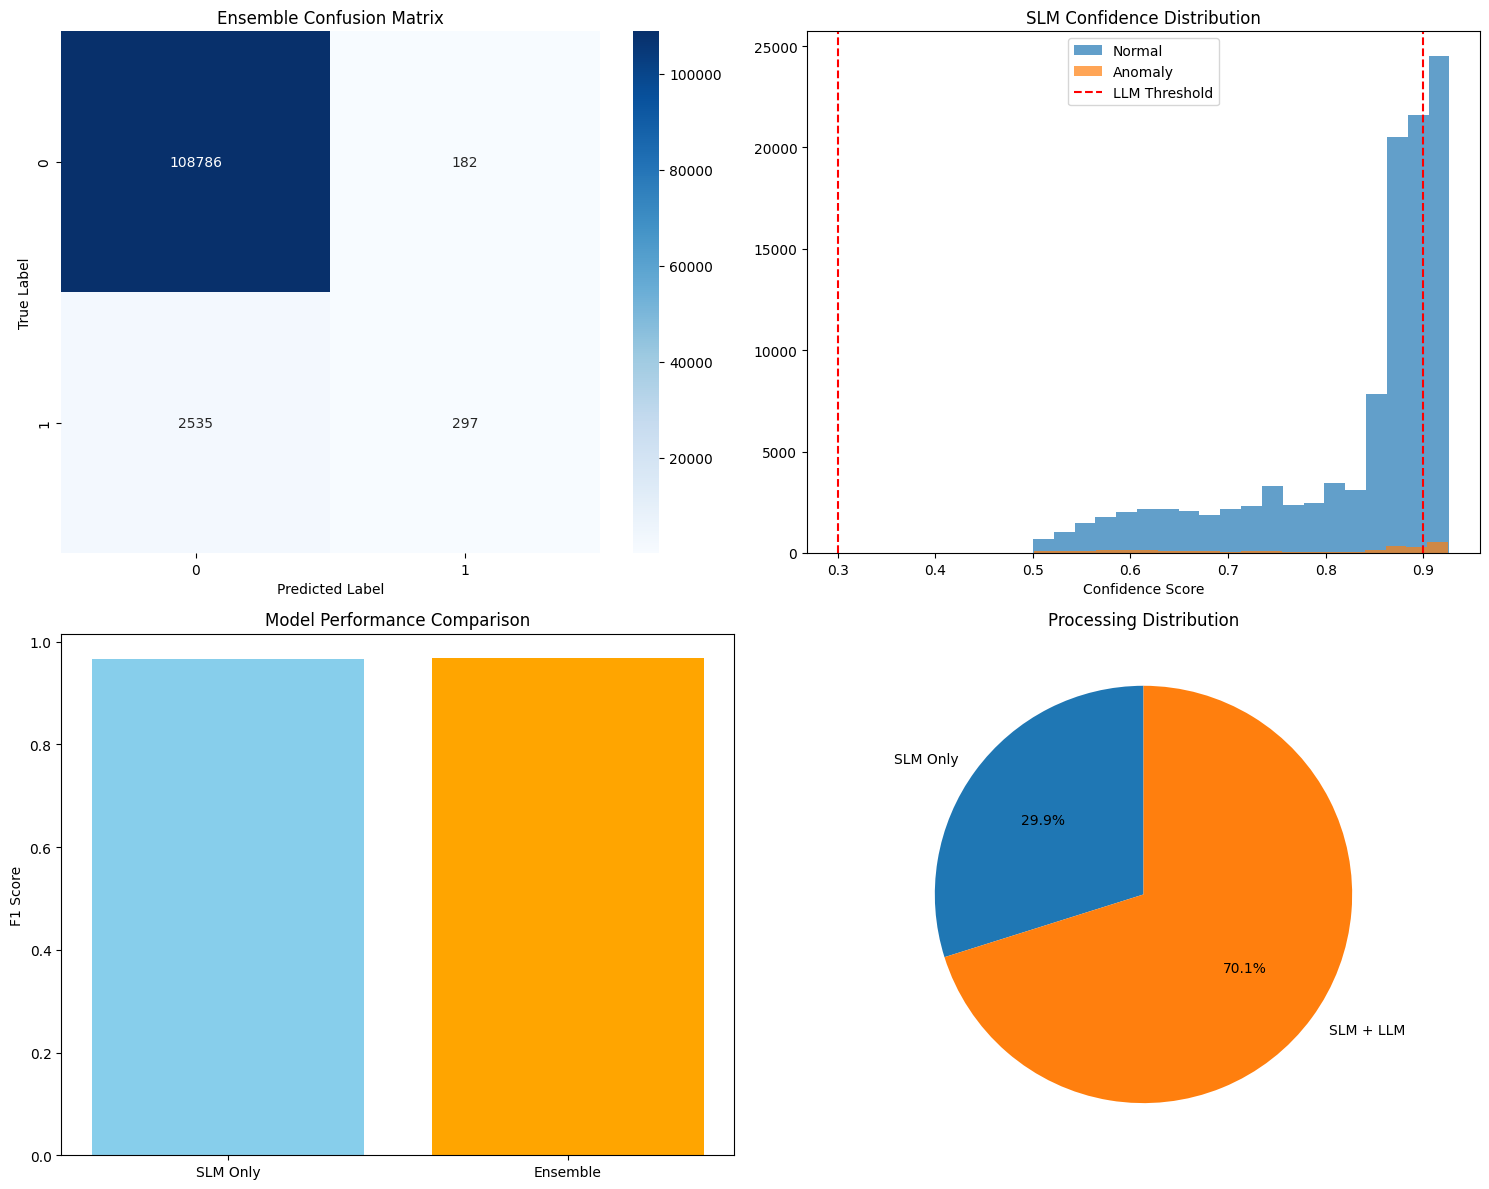

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Confusion Matrix
cm = confusion_matrix(y_test, final_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0])
axes[0,0].set_title('Ensemble Confusion Matrix')
axes[0,0].set_ylabel('True Label')
axes[0,0].set_xlabel('Predicted Label')

# Confidence distribution
axes[0,1].hist(slm_confidence[y_test == 0], alpha=0.7, label='Normal', bins=20)
axes[0,1].hist(slm_confidence[y_test == 1], alpha=0.7, label='Anomaly', bins=20)
axes[0,1].axvline(x=0.3, color='red', linestyle='--', label='LLM Threshold')
axes[0,1].axvline(x=0.9, color='red', linestyle='--')
axes[0,1].set_title('SLM Confidence Distribution')
axes[0,1].set_xlabel('Confidence Score')
axes[0,1].legend()

# Performance comparison
models = ['SLM Only', 'Ensemble']
f1_scores = [
    f1_score(y_test, slm_pred, average='weighted'),
    f1_score(y_test, final_predictions, average='weighted')
]
axes[1,0].bar(models, f1_scores, color=['skyblue', 'orange'])
axes[1,0].set_title('Model Performance Comparison')
axes[1,0].set_ylabel('F1 Score')

# Processing efficiency
total_samples = len(y_test)
llm_samples = test_uncertain_mask.sum()
slm_only_samples = total_samples - llm_samples

categories = ['SLM Only', 'SLM + LLM']
sample_counts = [slm_only_samples, llm_samples]
axes[1,1].pie(sample_counts, labels=categories, autopct='%1.1f%%', startangle=90)
axes[1,1].set_title('Processing Distribution')

plt.tight_layout()
plt.show()

In [33]:
print("FINAL PERFORMANCE SUMMARY")
print(f"Total test samples: {len(y_test)}")
print(f"Samples processed by SLM only: {slm_only_samples} ({slm_only_samples/len(y_test)*100:.1f}%)")
print(f"Samples processed by LLM: {llm_samples} ({llm_samples/len(y_test)*100:.1f}%)")

print("\nPerformance Metrics:")
print(f"SLM-only F1 Score: {f1_score(y_test, slm_pred, average='weighted'):.4f}")
print(f"Ensemble F1 Score: {f1_score(y_test, final_predictions, average='weighted'):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, slm_probs[:, 1]):.4f}")

print(f"\nProcessing Efficiency:")
print(f"Average processing per log: {(slm_only_samples * 5 + llm_samples * 100) / len(y_test):.1f}ms")
print(f"Estimated throughput: {1000 / ((slm_only_samples * 5 + llm_samples * 100) / len(y_test)):.0f} logs/second")


FINAL PERFORMANCE SUMMARY
Total test samples: 111800
Samples processed by SLM only: 33384 (29.9%)
Samples processed by LLM: 78416 (70.1%)

Performance Metrics:
SLM-only F1 Score: 0.9664
Ensemble F1 Score: 0.9672
ROC AUC Score: 0.7345

Processing Efficiency:
Average processing per log: 71.6ms
Estimated throughput: 14 logs/second
